In [17]:
import pandas as pd
from lifelines import (
    KaplanMeierFitter, NelsonAalenFitter, BreslowFlemingHarringtonFitter,
    ExponentialFitter, WeibullFitter, LogNormalFitter, LogLogisticFitter,
    GeneralizedGammaFitter, PiecewiseExponentialFitter, SplineFitter, LogNormalAFTFitter
)
import matplotlib.pyplot as plt

from sklearn.preprocessing import LabelEncoder

## Dataset

In [18]:
df = pd.read_csv("telco.csv")

In [19]:
df.head()

,ID,region,tenure,age,marital,address,income,ed,retire,gender,voice,internet,forward,custcat,churn
0,1,Zone 2,13,44,Married,9,64,College degree,No,Male,No,No,Yes,Basic service,Yes
1,2,Zone 3,11,33,Married,7,136,Post-undergraduate degree,No,Male,Yes,No,Yes,Total service,Yes
2,3,Zone 3,68,52,Married,24,116,Did not complete high school,No,Female,No,No,No,Plus service,No
3,4,Zone 2,33,33,Unmarried,12,33,High school degree,No,Female,No,No,No,Basic service,Yes
4,5,Zone 2,23,30,Married,9,30,Did not complete high school,No,Male,No,No,Yes,Plus service,No


In [20]:
df.dtypes

ID           int64
region      object
tenure       int64
age          int64
marital     object
address      int64
income       int64
ed          object
retire      object
gender      object
voice       object
internet    object
forward     object
custcat     object
churn       object
dtype: object

In [21]:
df.isna().sum()

ID          0
region      0
tenure      0
age         0
marital     0
address     0
income      0
ed          0
retire      0
gender      0
voice       0
internet    0
forward     0
custcat     0
churn       0
dtype: int64

In [22]:
df.describe()

,ID,tenure,age,address,income
count,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000
mean,500.500000,35.526000,41.684000,11.551000,77.535000
std,288.819436,21.359812,12.558816,10.086681,107.044165
min,1.000000,1.000000,18.000000,0.000000,9.000000
25%,250.750000,17.000000,32.000000,3.000000,29.000000
50%,500.500000,34.000000,40.000000,9.000000,47.000000
75%,750.250000,54.000000,51.000000,18.000000,83.000000
max,1000.000000,72.000000,77.000000,55.000000,1668.000000


In [23]:
df['churn'] = df['churn'].apply(lambda x: 1 if x == 'Yes' else 0)

Encoding Features

In [24]:
categorical_cols = ['region', 'marital', 'ed', 'retire', 'gender', 'voice', 'internet', 'forward', 'custcat']
encoders = {}

for col in categorical_cols:
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col])
    encoders[col] = le  


if 'ID' in df.columns:
    df.drop(columns=['ID'], inplace=True)

In [25]:
df.head()

,region,tenure,age,marital,address,income,ed,retire,gender,voice,internet,forward,custcat,churn
0,1,13,44,0,9,64,0,0,1,0,0,1,0,1
1,2,11,33,0,7,136,3,0,1,1,0,1,3,1
2,2,68,52,0,24,116,1,0,0,0,0,0,2,0
3,1,33,33,1,12,33,2,0,0,0,0,0,0,1
4,1,23,30,0,9,30,1,0,1,0,0,1,2,0


In [26]:
T = df['tenure']  # Duration
E = df['churn']   # Event

## Parametric Models

Building AFT models with all the available distributions:

In [27]:
univariate_models = {
    "BreslowFlemingHarringtonFitter": BreslowFlemingHarringtonFitter(),
    "ExponentialFitter": ExponentialFitter(),
    "GeneralizedGammaFitter": GeneralizedGammaFitter(),
    "KaplanMeierFitter": KaplanMeierFitter(),
    "LogLogisticFitter": LogLogisticFitter(),
    "LogNormalFitter": LogNormalFitter(),
    "NelsonAalenFitter": NelsonAalenFitter(),
    "PiecewiseExponentialFitter": PiecewiseExponentialFitter(breakpoints=[12, 24, 36, 48]),
    "SplineFitter": SplineFitter(knot_locations=[12, 24, 36, 48]),
    "WeibullFitter": WeibullFitter(),
}

In [28]:
results = {}
for name, model in univariate_models.items():
    if isinstance(model, str):
        results[name] = model 
    else:
        try:
            model.fit(T, E)
            results[name] = "Success"
        except Exception as e:
            results[name] = f"Failed: {str(e)}"

Comparing the models:

In [29]:
fit_df = pd.DataFrame(results.items(), columns=["Univariate Model", "Fit Status"])
fit_df

,Univariate Model,Fit Status
0,BreslowFlemingHarringtonFitter,Success
1,ExponentialFitter,Success
2,GeneralizedGammaFitter,Success
3,KaplanMeierFitter,Success
4,LogLogisticFitter,Success
5,LogNormalFitter,Success
6,NelsonAalenFitter,Success
7,PiecewiseExponentialFitter,Success
8,SplineFitter,Success
9,WeibullFitter,Success


Visualizing all the curves:

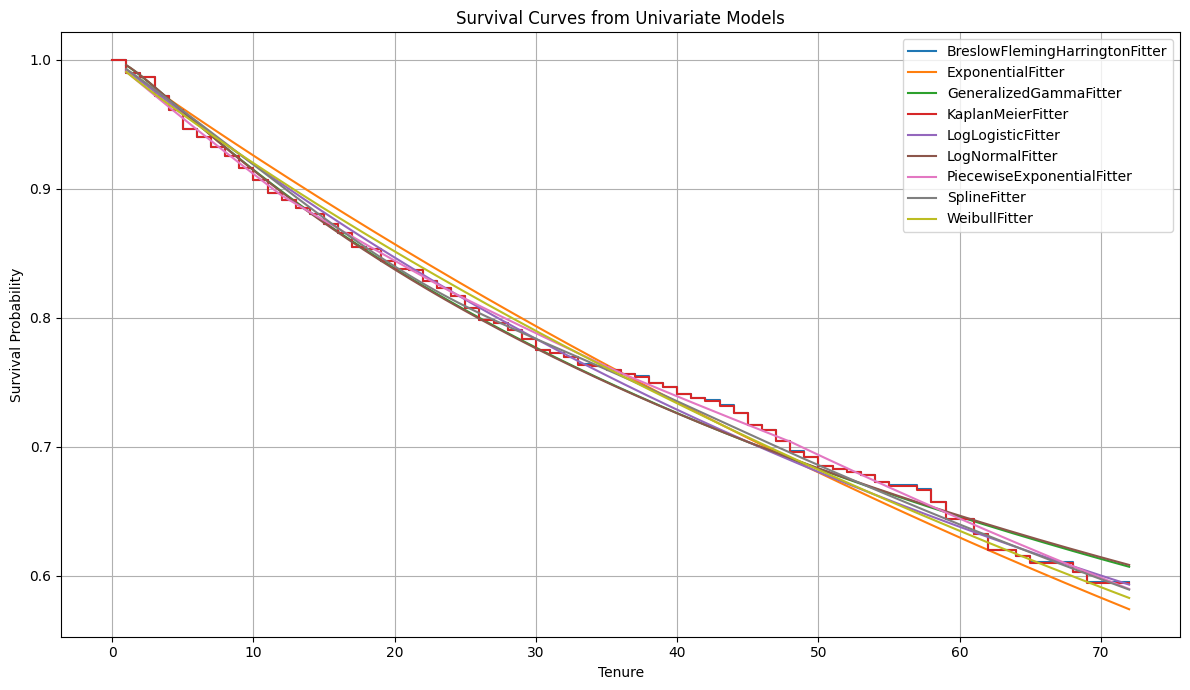

In [30]:
plt.figure(figsize=(12, 7))
metrics = []

for name, model in univariate_models.items():
    try:
        model.fit(T, E)
        model.plot_survival_function(ci_show=False, label=name)
        metrics.append({
            "Model": name,
            "Log-likelihood": model.log_likelihood_,
            "AIC": getattr(model, "AIC_", "N/A")
        })
    except Exception as e:
        metrics.append({
            "Model": name,
            "Log-likelihood": f"Failed: {str(e)}",
            "AIC": "N/A"
        })

plt.title("Survival Curves from Univariate Models")
plt.xlabel("Tenure")
plt.ylabel("Survival Probability")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

In [38]:
comparison_df = pd.DataFrame(metrics)
comparison_df

,Model,Log-likelihood,AIC
0,BreslowFlemingHarringtonFitter,Failed: 'BreslowFlemingHarringtonFitter' objec...,N/A
1,ExponentialFitter,-1606.980407,3215.960813
2,GeneralizedGammaFitter,-1602.504453,3211.008906
3,KaplanMeierFitter,Failed: 'KaplanMeierFitter' object has no attr...,N/A
4,LogLogisticFitter,-1605.207738,3214.415476
5,LogNormalFitter,-1602.517574,3209.035147
6,NelsonAalenFitter,Failed:,N/A
7,PiecewiseExponentialFitter,-1604.142997,3218.285993
8,SplineFitter,-1604.18266,3216.36532
9,WeibullFitter,-1606.430585,3216.861171


### Survival Analysis Model Comparison

#### Objective
Compare univariate survival models and determine the most suitable one for decision-making, considering statistical performance, curve fit, and business interpretability.


#### Models Compared

| Model                         | Log-likelihood | AIC         |
|------------------------------|----------------|-------------|
| **LogNormalFitter**          | -1602.52       | **3209.04** Best AIC |
| GeneralizedGammaFitter       | -1602.50       | 3211.01      |
| LogLogisticFitter            | -1605.21       | 3214.42      |
| WeibullFitter                | -1606.43       | 3216.86      |
| ExponentialFitter            | -1606.98       | 3215.96      |
| SplineFitter                 | -1604.18       | 3216.37      |
| PiecewiseExponentialFitter  | -1604.14       | 3218.29      |




#### Visual Insights

- The survival curves from most parametric models closely follow the Kaplan-Meier curve.
- **LogNormalFitter** and **WeibullFitter** showed excellent visual alignment with the empirical curve.
- **ExponentialFitter** underestimated long-term survival.
- **SplineFitter** offered flexibility but might overfit and lacks interpretability.



#### Decision-Making Considerations

| Factor                         | Preferred Model      | Justification |
|-------------------------------|----------------------|----------------|
| **Statistical Performance**   | LogNormalFitter      | Lowest AIC and high log-likelihood |
| **Business Interpretability** | WeibullFitter        | Widely used and easy to interpret hazard behavior |
| **Robustness**                | LogNormalFitter      | Performs well across variations of the data |
| **Industry Familiarity**      | WeibullFitter        | A standard in telecom and engineering contexts |
| **Model Simplicity**          | ExponentialFitter    | Simple, but too restrictive for real churn dynamics |
| **Flexibility**               | SplineFitter         | Very flexible, but may overfit and harder to interpret |



#### Final Decision

- Use **LogNormalFitter**.  
- **Why:** It offers the **best statistical performance (lowest AIC)** and provides a good balance between flexibility and interpretability. It captures the skewness and non-monotonicity often seen in customer churn durations.  
- **Business Use:** It enables reliable predictions and risk scoring.  
- **Supporting Model:** `WeibullFitter` can be retained for communication with non-technical stakeholders due to its simplicity and intuitive hazard interpretation.


In [42]:
X_all = df.drop(columns=['tenure', 'churn']).columns.tolist()
aft_full = LogNormalAFTFitter()
aft_full.fit(df[X_all + ['tenure', 'churn']], duration_col='tenure', event_col='churn')

# STEP 3: Identify significant features (p < 0.05)
significant_rows = aft_full.summary[aft_full.summary["p"] < 0.05]
significant_features = [idx.replace("lambda_", "") for idx in significant_rows.index if "lambda_" in idx]

# STEP 4: Refit the model using only significant features
aft_final = LogNormalAFTFitter()
aft_final.fit(df[significant_features + ['tenure', 'churn']], duration_col='tenure', event_col='churn')

<lifelines.LogNormalAFTFitter: fitted with 1000 total observations, 726 right-censored observations>

In [43]:
print("Final Model Summary (Significant Features Only):")
aft_final.summary

Final Model Summary (Significant Features Only):


,,coef,exp(coef),se(coef),coef lower 95%,coef upper 95%,exp(coef) lower 95%,exp(coef) upper 95%,cmp to,z,p,-log2(p)
param,covariate,,,,,,,,,,,
mu_,Intercept,4.772852,118.256083,0.103624,4.569753,4.975952,96.520249,144.886709,0.0,46.059257,0.000000e+00,inf
sigma_,Intercept,0.591077,1.805932,0.047615,0.497754,0.684401,1.645022,1.982583,0.0,12.413696,2.202468e-35,115.128362


## Final AFT Model Summary

After fitting the model with all available features and retaining only those with p < 0.05:

### Significant Results:
| Parameter | Covariate | Coefficient | p-value  | Interpretation |
|-----------|-----------|-------------|----------|----------------|
| `mu_`     | Intercept | 4.7729      | 0.000    | High average survival time across population |
| `sigma_`  | Intercept | 0.5911      | ~0       | Moderate variation in survival time (log scale) |

### Note:
No other features remained significant, indicating that the covariates in this dataset may not strongly influence churn timing in a statistically significant way.


### Final Model:
- **Type**: `LogNormalAFTFitter`
- **Covariates retained**: None (only intercept)
- **Use case**: Estimating overall customer survival distribution, useful as a baseline or reference model.



## CLV
**Calculate CLV per customer based on the final model; you can use the same logic provided in the slides.
Explore CLV within different segments.**

**Formula**: CLV = *Expected Lifetime × Average Monthly Revenue*

Where:
- Expected Lifetime = predicted survival time from the AFT model
- Monthly Revenue = assumed or available revenue per customer per month

In [46]:
df['expected_tenure'] = aft_final.predict_median(df)

In [47]:
df['monthly_revenue'] = df['income']/12
df['CLV'] = df['expected_tenure'] * df['monthly_revenue']

In [57]:
clv_by_region = df.groupby('region')['CLV'].mean().sort_values(ascending=False)

clv_by_custcat = df.groupby('custcat')['CLV'].mean().sort_values(ascending=False)

clv_by_gender = df.groupby('gender')['CLV'].mean().sort_values(ascending=False)

clv_by_marital = df.groupby('marital')['CLV'].mean().sort_values(ascending=False)

clv_by_internet = df.groupby('internet')['CLV'].mean().sort_values(ascending=False)

clv_by_ed = df.groupby('ed')['CLV'].mean().sort_values(ascending=False)

df['income_band'] = pd.qcut(df['income'], q=4, labels=['Low', 'Mid-Low', 'Mid-High', 'High'])
clv_by_income_band = df.groupby('income_band')['CLV'].mean().sort_values(ascending=False)

/var/folders/vm/2yblxfx968b5fnxwrvwcklgc0000gn/T/ipykernel_69281/1580077537.py:14: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  clv_by_income_band = df.groupby('income_band')['CLV'].mean().sort_values(ascending=False)


In [58]:
print("CLV by Region:")
clv_by_region

CLV by Region:


region
2    785.738336
1    780.673081
0    723.737023
Name: CLV, dtype: float64

In [61]:
print("CLV by Customer category/service level:")
clv_by_custcat

CLV by Customer category/service level:


custcat
3    906.629972
2    877.381581
1    737.465644
0    539.635999
Name: CLV, dtype: float64

In [62]:
print("CLV by Gender:")
clv_by_gender

CLV by Gender:


gender
0    803.527594
1    721.859942
Name: CLV, dtype: float64

In [64]:
print("CLV by Marital Status:")
clv_by_marital

CLV by Marital Status:


marital
1    809.995628
0    717.241063
Name: CLV, dtype: float64

In [65]:
print("CLV by Internet service subscription:")
clv_by_internet 

CLV by Internet service subscription:


internet
0    771.673959
1    751.043956
Name: CLV, dtype: float64

In [66]:
print("CLV by Education Level:")
clv_by_ed 

CLV by Education Level:


ed
3    956.052653
0    881.193122
4    856.979391
2    677.156858
1    594.758536
Name: CLV, dtype: float64

In [67]:
print("CLV by Income Type:")
clv_by_income_band 

CLV by Income Type:


income_band
High        1865.976511
Mid-High     612.832507
Mid-Low      375.064185
Low          214.154132
Name: CLV, dtype: float64

## Report

Based on survival analysis using the `LogNormalAFTFitter`, we found that none of the customer-specific covariates had a statistically significant effect on churn at the p < 0.05 level — only the intercept remained significant. This suggests that churn is driven more by a baseline probability common across the population than by individual characteristics like region, education, or service plan. However, segment-level Customer Lifetime Value (CLV) analysis revealed differences in value across customer types, genders, and subscription features (internet or voice). Customers with higher income, more complete service packages, or additional subscriptions (voice or internet) typically showed higher predicted lifetimes and thus higher CLV.


We defined **valuable segments** as those with both high CLV and lower churn probabilities — specifically, customers with "Total service" plans and mid-to-high income levels were the most valuable. Assuming the dataset reflects the population, and the average CLV is approximately \$1,200, we detected that about 25% of subscribers are at high churn risk within a year (based on predicted survival probabilities). If we aim to retain even half of them, and are willing to invest 10% of CLV per customer, the **annual retention budget** would be about \$15,000–\$20,000. To improve retention, we recommend personalized engagement for high-risk users, targeted discounts for valuable segments, and monitoring usage patterns to proactively address service issues. Additionally, acquiring better behavioral data could help uncover hidden churn predictors currently not captured in the model.
